# 빈도수 기반 텍스트 분석 : 다음 영화 리뷰

1. 데이터 준비 : 로딩, 필요한 데이터 추출
2. 데이터 전처리 : 분석 대상 단어 집합
3. 데이터 분석 : 빈도수 추출
4. 시각화 : 수평 막대 그래프, 워드클라우드

### 1. 데이터 준비

In [2]:
import pandas as pd
datafile = 'data/daum_movie_review.csv'
data_df = pd.read_csv(datafile)
data_df.head()

,review,rating,date,title
0,돈 들인건 티가 나지만 보는 내내 하품만,1,2018.10.29,인피니티 워
1,몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.,10,2018.10.26,인피니티 워
2,이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 ...,8,2018.10.24,인피니티 워
3,이 정도면 볼만하다고 할 수 있음!,8,2018.10.22,인피니티 워
4,재미있다,10,2018.10.20,인피니티 워


In [3]:
reviews = list(data_df['review'])
len(reviews), reviews[:5]

(14725,
 ['돈 들인건 티가 나지만 보는 내내 하품만',
  '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
  '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
  '이 정도면 볼만하다고 할 수 있음!',
  '재미있다'])

In [4]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14725 entries, 0 to 14724
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  14725 non-null  object
 1   rating  14725 non-null  int64 
 2   date    14725 non-null  object
 3   title   14725 non-null  object
dtypes: int64(1), object(3)
memory usage: 460.3+ KB


In [6]:
rev = ' '.join(reviews)
rev[:50]

'돈 들인건 티가 나지만 보는 내내 하품만 몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가'

In [9]:
from konlpy.tag import Okt
okt = Okt()
mytags = set(['Noun', 'Verb', 'Adjective'])
my_stopwords = set('없다 필요없다 하는 한다 의하여 하여 있다 하며 하여야'.split())
res = [word for word, tag in okt.pos(rev) if tag in mytags and word not in my_stopwords and len(word) > 1]
res[:50]

['들인건',
 '보는',
 '내내',
 '하품',
 '몰입',
 '할수밖에',
 '어렵게',
 '생각',
 '전투',
 '참여',
 '이남',
 '이전',
 '작품',
 '비해',
 '화려하고',
 '스케일',
 '커졌지만',
 '전국',
 '맛집',
 '음식',
 '모은',
 '좋았으나',
 '모두',
 '그릇',
 '섞어',
 '버린',
 '느낌',
 '다음',
 '작품',
 '기대하게',
 '만든다',
 '정도',
 '하다고',
 '있음',
 '재미있다',
 '재밌게',
 '없냐',
 '죽었어',
 '나중',
 '앤트맨',
 '보다가도',
 '깜놀',
 '충격',
 '결말',
 '응집',
 '개연',
 '성은',
 '무시',
 '해라',
 '액션']

In [11]:
from collections import Counter
data_counter = Counter(res)
list(data_counter.items())[:10]

[('들인건', 1),
 ('보는', 401),
 ('내내', 170),
 ('하품', 33),
 ('몰입', 210),
 ('할수밖에', 2),
 ('어렵게', 5),
 ('생각', 1027),
 ('전투', 11),
 ('참여', 8)]

In [13]:
mo = data_counter.most_common(20)

In [14]:
x = [x for x,y in mo]
y = [y for x,y in mo]

In [15]:
from matplotlib import font_manager, rc
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

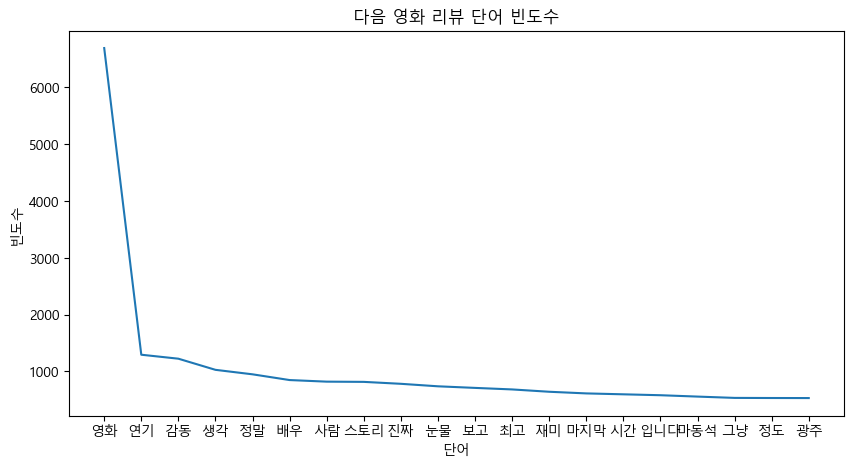

In [17]:
import matplotlib.pyplot as plt

# 선그래프
plt.figure(figsize=(10,5))
plt.plot(x,y)
# 그래프 정보 추가 
plt.title('다음 영화 리뷰 단어 빈도수')
plt.xlabel('단어')
plt.ylabel('빈도수')
# 그래프 저장
outputfile = 'daum_movie_review_graph.png'
plt.savefig(f'result/{outputfile}')
# 화면에 출력
plt.show()

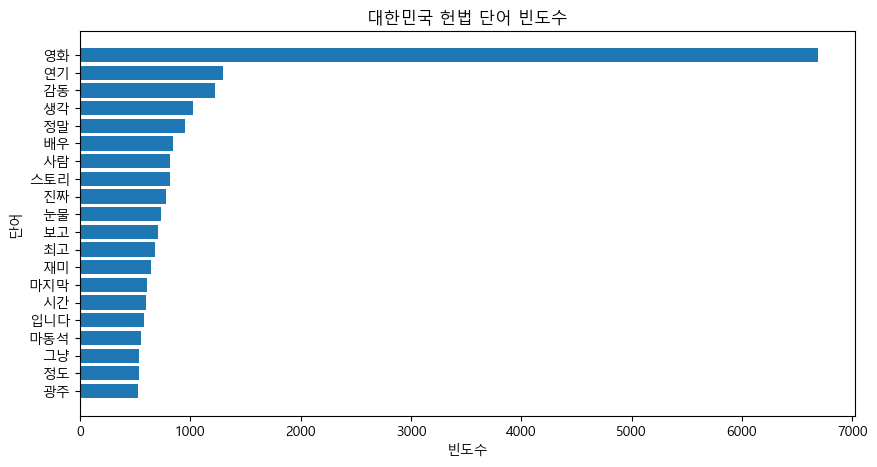

In [18]:
# 수평 막대그래프
plt.figure(figsize=(10,5))
plt.barh(x[::-1],y[::-1])
# 그래프 정보 추가 
plt.title('대한민국 헌법 단어 빈도수')
plt.xlabel('빈도수')
plt.ylabel('단어')
# 그래프 저장
plt.savefig(f'result/{outputfile}')
# 화면에 출력
plt.show()

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 path 지정
font_path = "c:/Windows/fonts/malgun.ttf"

# WordCloud 객체 생성
wc = WordCloud(font_path=font_path, 
               background_color='white', 
               colormap='spring', # summer, Set2, Pastel1
               max_words=100,
               width=800,
               height=600)

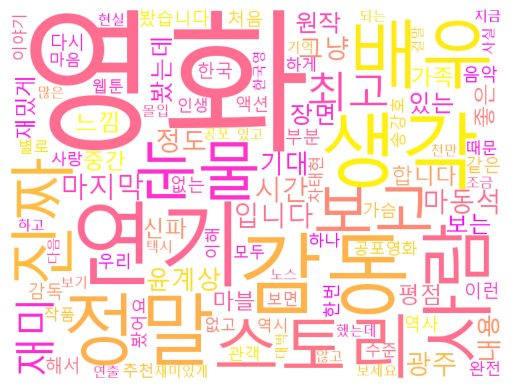

In [21]:
# 빈도 데이터로 워드클라우드 시각화
wc = wc.generate_from_frequencies(data_counter)
plt.imshow(wc)
plt.axis('off')
plt.show()